<a href="https://colab.research.google.com/github/amarchenac-ops/repositoryanthony/blob/main/%5B00%5D%20-%20Workshops/Workshop_ML_PartTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Final — Machine Learning Integrado




## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).  

**Columnas principales:**  
- Order ID / Customer ID: identificadores únicos de pedido y cliente  
- Order Date / Ship Mode: fecha y modo de envío  
- Segment: tipo de cliente (Consumer, Corporate, Home Office)  
- Region / State / City: localización geográfica  
- Category / Sub-Category: categoría de producto  
- Sales: importe de la venta  
- Quantity: número de unidades vendidas  
- Discount: descuento aplicado (%)  
- Profit: beneficio asociado al pedido  

**Problema de negocio (ejemplo):**  
“Queremos identificar qué clientes tienen mayor probabilidad de generar pérdidas, predecir su volumen de compra y segmentarlos para diseñar campañas de marketing más eficaces.”

**Importante:**  
- Este dataset es una **base común** para quienes lo deseen.  
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

# Qué problema (o problemas) de negocio quieres resolver?
Nuestro problema de negocio es saber cuál es la posición ideal de un jugador nuevo, además, también queremos saber el valor de la clausula de dicho jugador, en función de la información que poseemos.

# Fase 1 - EDA y primeros modelos

#Descripción del Dataset
Contenido: Este dataset está compuesto por 2.400 registros de jugadores de fútbol, centrados en perfiles jóvenes y en proyección. Combina métricas de rendimiento deportivo (técnica, físico, inteligencia) con variables de impacto comercial y financiero.
Contexto: Se trata de una base de datos híbrida que cruza el scouting tradicional con el marketing de influencia. Incluye indicadores específicos como el costo de patrocinio y la presencia en mercados estratégicos.
###Propósito:
A partir de este dataset identificar talento con potencial para facilitar la selección de un embajador de marca mediante el cruce de rendimiento atlético y alcance digital, asegurando que el perfil sea coherente con la expansión geográfica de una fintech.
###⁠Justificación de la Elección del Dataset
Este dataset resulta adecuado para responder a la pregunta sobre cual promesa futbolista debe ser el embajador de la marca Revolut ya que está orientado al entorno fintech, incorporando variables como PAIS REVOLUT, lo que sugiere una alineación previa con los mercados donde opera la marca. Además, no se limita únicamente al rendimiento deportivo tradicional, sino que combina métricas como seguidores en Instagram y un índice total deportivo, permitiendo evaluar tanto el desempeño en el campo como la visibilidad mediática. Esto facilita estimar el potencial retorno de inversión (ROI) de un posible patrocinio.
Por otro lado, el dataset también permite un análisis financiero y comparativo sólido, ya que incluye variables clave como salario, cláusula y costo total de patrocinio, lo que ayuda a medir la viabilidad económica antes de tomar decisiones. A esto se suma la presencia de datos normalizados, que hacen posible comparar jugadores de distintas ligas o posiciones de forma más equitativa, mejorando la segmentación y reduciendo el riesgo en la selección del jugador ideal.
###Identificación de Variables
Dada la extensión del dataset (51 columnas), he agrupado y seleccionado las variables más críticas para el análisis de marketing y scouting:

####Nombre de la Variable	Y Tipo de Dato

Nombre: Texto

Nacionalidad: Texto

Seguidores Insta: Numérico

Año de nacimiento: Numérico

valor: Numérico

clausula:	Numérico

Total sponsorship cost:	Numérico

Indice total deportivo:	Numérico

PAIS REVOLUT:	Texto

técnica / visión:	Numérico
###⁠Análisis de Calidad de Datos
•⁠  ⁠Duplicados: Se han detectado 0 duplicados, lo que confirma que la limpieza previa del archivo fue efectiva.

•⁠  ⁠Valores Nulos: El dataset no cuenta con valores nulos

In [4]:
# Imports - añade aquí las librerías que vayas a utilizar en el notebook

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
# etc

In [5]:
# Carga aquí tus datos - puedes elegir el dataset propuesto u otro de tu
# elección.
df = pd.read_csv('/content/jugadores_con_seguidores_rellenos.csv', sep=';')
df

,id_jugador,nombre,Nacionalidad,Seguidores Insta,Año de nacimiento,puesto,comienzo,valor,salario,clausula,...,Técnica,Inteligencia,Indice total deportivo,PAIS REVOLUT,LOGARITMO INSTAGRAM,NORM_PERF,NORM_SOCIAL,NORM_AUDIENCE,NORM_REPUTACION,NORM_COST
0,1723,R. Vata,Albania,24800,2005,MCO,16/7/2021,1500000,5000,3600000,...,62.56,156.4,101.89,0,4.394.469.192.347.430,0.257804,NaN,NaN,NaN,NaN
1,2179,M. Berisha,Albania,26400,2004,MC,18/8/2022,625000,2000,1500000,...,63.88,143.2,94.23,0,4.421.620.377.106.830,0.201700,NaN,NaN,NaN,NaN
2,2953,S. Shpendi,Albania,31200,2003,DC,5/8/2023,1200000,2000,2400000,...,60.69,133.2,89.79,0,4.494.168.513.490.300,0.169210,NaN,NaN,NaN,NaN
3,3336,A. Pajaziti,Albania,12400,2003,MCD,1/7/2019,1100000,9000,2300000,...,62.69,160.4,102.24,0,40.934.567.074.986.000,0.260369,NaN,NaN,NaN,NaN
4,23,L. Ben Farhat,Alemania,19500,2007,MD,9/3/2024,400000,500,890000,...,60.25,134.4,88.31,1,4.290.056.882.303.360,0.158384,NaN,NaN,NaN,0.002502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,675,J. Sabobo Banda,Zambia,8307,2006,MCO,16/1/2024,375000,500,919000,...,58.63,137.2,89.43,0,39.194.964.878.630.600,0.166576,NaN,NaN,NaN,NaN
2396,3665,K. Mutandwa,Zambia,3333,2003,DC,3/3/2024,240000,3000,480000,...,49.25,130.0,84.89,0,35.229.655.954.919.800,0.133377,NaN,NaN,NaN,NaN
2397,989,P. Madanha,Zimbabue,2592,2005,MD,10/12/2022,375000,500,544000,...,54.44,152.6,97.86,0,34.138.025.167.693.500,0.228279,NaN,NaN,NaN,NaN
2398,2755,T. Chirewa,Zimbabue,8972,2004,MD,18/9/2023,575000,6000,1500000,...,60.13,149.2,97.19,0,39.529.376.677.509.800,0.223372,NaN,NaN,NaN,NaN


## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección  
2. Identificación de variables, tipos, nulos y duplicados  
3. Limpieza de datos  
4. Creación de nuevas variables (feature engineering)  
5. Transformaciones: encoding y escalado  
6. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)


In [6]:
# Desarrolla tu código de EDA y preparación de datos
columnas_a_eliminar = ['NORM_SOCIAL', 'NORM_AUDIENCE', 'NORM_REPUTACION', 'NORM_COST']
df_limpio = df.drop(columns=columnas_a_eliminar, errors='ignore')
df_limpio

,id_jugador,nombre,Nacionalidad,Seguidores Insta,Año de nacimiento,puesto,comienzo,valor,salario,clausula,...,pase,regates_reflejos,fisico,Performance físico,Técnica,Inteligencia,Indice total deportivo,PAIS REVOLUT,LOGARITMO INSTAGRAM,NORM_PERF
0,1723,R. Vata,Albania,24800,2005,MCO,16/7/2021,1500000,5000,3600000,...,54,70,53,68.54,62.56,156.4,101.89,0,4.394.469.192.347.430,0.257804
1,2179,M. Berisha,Albania,26400,2004,MC,18/8/2022,625000,2000,1500000,...,59,58,63,59.31,63.88,143.2,94.23,0,4.421.620.377.106.830,0.201700
2,2953,S. Shpendi,Albania,31200,2003,DC,5/8/2023,1200000,2000,2400000,...,46,64,58,61.00,60.69,133.2,89.79,0,4.494.168.513.490.300,0.169210
3,3336,A. Pajaziti,Albania,12400,2003,MCD,1/7/2019,1100000,9000,2300000,...,59,61,65,64.23,62.69,160.4,102.24,0,40.934.567.074.986.000,0.260369
4,23,L. Ben Farhat,Alemania,19500,2007,MD,9/3/2024,400000,500,890000,...,58,62,42,54.92,60.25,134.4,88.31,1,4.290.056.882.303.360,0.158384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,675,J. Sabobo Banda,Zambia,8307,2006,MCO,16/1/2024,375000,500,919000,...,50,60,41,56.54,58.63,137.2,89.43,0,39.194.964.878.630.600,0.166576
2396,3665,K. Mutandwa,Zambia,3333,2003,DC,3/3/2024,240000,3000,480000,...,40,53,60,60.38,49.25,130.0,84.89,0,35.229.655.954.919.800,0.133377
2397,989,P. Madanha,Zimbabue,2592,2005,MD,10/12/2022,375000,500,544000,...,48,56,70,68.31,54.44,152.6,97.86,0,34.138.025.167.693.500,0.228279
2398,2755,T. Chirewa,Zimbabue,8972,2004,MD,18/9/2023,575000,6000,1500000,...,52,60,55,64.92,60.13,149.2,97.19,0,39.529.376.677.509.800,0.223372


In [7]:
df_limpio.head()

,id_jugador,nombre,Nacionalidad,Seguidores Insta,Año de nacimiento,puesto,comienzo,valor,salario,clausula,...,pase,regates_reflejos,fisico,Performance físico,Técnica,Inteligencia,Indice total deportivo,PAIS REVOLUT,LOGARITMO INSTAGRAM,NORM_PERF
0,1723,R. Vata,Albania,24800,2005,MCO,16/7/2021,1500000,5000,3600000,...,54,70,53,68.54,62.56,156.4,101.89,0,4.394.469.192.347.430,0.257804
1,2179,M. Berisha,Albania,26400,2004,MC,18/8/2022,625000,2000,1500000,...,59,58,63,59.31,63.88,143.2,94.23,0,4.421.620.377.106.830,0.201700
2,2953,S. Shpendi,Albania,31200,2003,DC,5/8/2023,1200000,2000,2400000,...,46,64,58,61.00,60.69,133.2,89.79,0,4.494.168.513.490.300,0.169210
3,3336,A. Pajaziti,Albania,12400,2003,MCD,1/7/2019,1100000,9000,2300000,...,59,61,65,64.23,62.69,160.4,102.24,0,40.934.567.074.986.000,0.260369
4,23,L. Ben Farhat,Alemania,19500,2007,MD,9/3/2024,400000,500,890000,...,58,62,42,54.92,60.25,134.4,88.31,1,4.290.056.882.303.360,0.158384


In [8]:
df_limpio.isnull().sum()

,0
id_jugador,0
nombre,0
Nacionalidad,0
Seguidores Insta,0
Año de nacimiento,0
puesto,0
comienzo,0
valor,0
salario,0
clausula,0


In [9]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 53 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_jugador              2400 non-null   int64  
 1   nombre                  2400 non-null   object 
 2   Nacionalidad            2400 non-null   object 
 3   Seguidores Insta        2400 non-null   int64  
 4   Año de nacimiento       2400 non-null   int64  
 5   puesto                  2400 non-null   object 
 6   comienzo                2400 non-null   object 
 7   valor                   2400 non-null   int64  
 8   salario                 2400 non-null   int64  
 9   clausula                2400 non-null   int64  
 10  TOTAL SPONSORSHIP COST  2400 non-null   int64  
 11  centros                 2400 non-null   int64  
 12  definicion              2400 non-null   int64  
 13  precision_cabeza        2400 non-null   int64  
 14  pases_cortos            2400 non-null   

In [10]:
import datetime

# ROI Social (Seguidores por cada euro de salario)
df_limpio['ROI_SOCIAL'] = df_limpio['Seguidores Insta'] / df_limpio['salario'].replace(0, 1)

# Calcular Edad (Variable auxiliar necesaria)
anio_actual = datetime.datetime.now().year
df_limpio['EDAD'] = anio_actual - df_limpio['Año de nacimiento']

# Ratio Técnica vs Físico
df_limpio['RATIO_TECNICO_FISICO'] = df_limpio['Técnica'] / df_limpio['Performance físico'].replace(0, 1)

# Eficiencia de Costo (Costo por cada punto de índice deportivo)
df_limpio['COSTO_POR_CALIDAD'] = df_limpio['valor'] / df_limpio['Indice total deportivo'].replace(0, 1)

# Clasificación de Potencial (Lógica de experto)
def clasificar_potencial(row):
    if row['EDAD'] <= 23 and row['Indice total deportivo'] >= 90:
        return 'Promesa Elite'
    elif row['EDAD'] <= 23 and row['Indice total deportivo'] < 90:
        return 'Joven en Desarrollo'
    else:
        return 'Jugador Consolidado'

df_limpio['CATEGORIA_POTENCIAL'] = df_limpio.apply(clasificar_potencial, axis=1)

display(df_limpio[['nombre', 'ROI_SOCIAL', 'EDAD', 'COSTO_POR_CALIDAD', 'CATEGORIA_POTENCIAL']].head())

,nombre,ROI_SOCIAL,EDAD,COSTO_POR_CALIDAD,CATEGORIA_POTENCIAL
0,R. Vata,4.960000,21,14721.758759,Promesa Elite
1,M. Berisha,13.200000,22,6632.707206,Promesa Elite
2,S. Shpendi,15.600000,23,13364.517207,Joven en Desarrollo
3,A. Pajaziti,1.377778,23,10758.998435,Promesa Elite
4,L. Ben Farhat,39.000000,19,4529.498358,Joven en Desarrollo


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/tmp/ipykernel_1437/2332436206.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


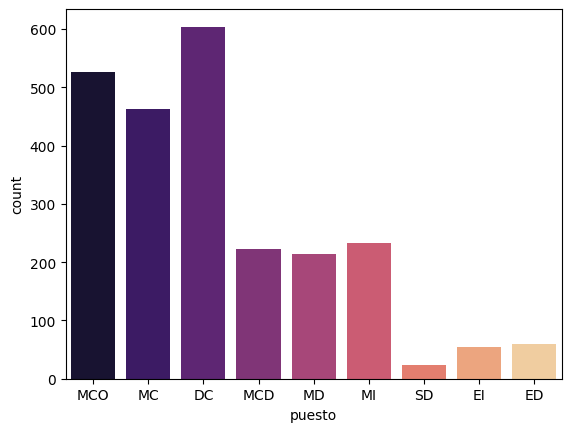

In [12]:

ax = sns.countplot(
    x='puesto',
    data=df_limpio,
    palette='magma'
)

Text(0.5, 1.0, 'Distribución Normalizada de Seguidores (Log Scale)')

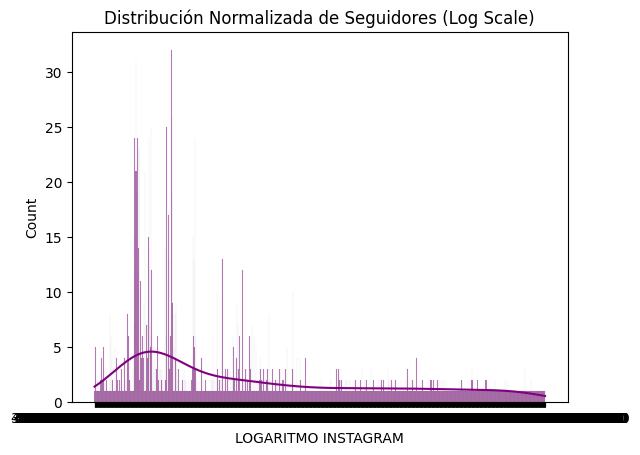

In [13]:
sns.histplot(df_limpio['LOGARITMO INSTAGRAM'], kde=True, color='purple')
plt.title('Distribución Normalizada de Seguidores (Log Scale)')

/tmp/ipykernel_1437/3279383193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='valor', y='nombre', data=top_10, palette='viridis')


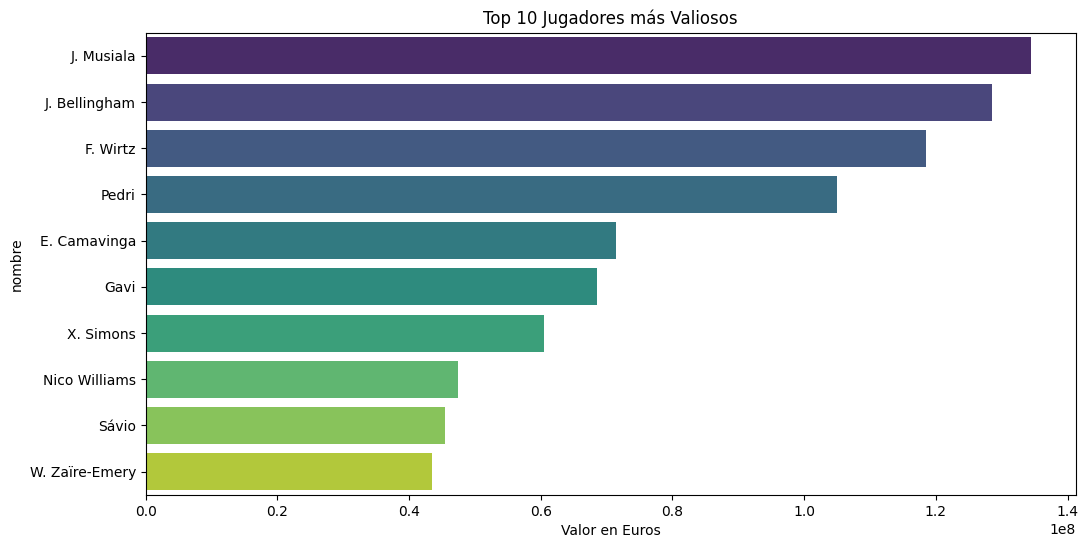

In [14]:
# Top 10 jugadores por Valor
top_10 = df_limpio.nlargest(10, 'valor')

plt.figure(figsize=(12, 6))
sns.barplot(x='valor', y='nombre', data=top_10, palette='viridis')
plt.title('Top 10 Jugadores más Valiosos')
plt.xlabel('Valor en Euros')
plt.show()

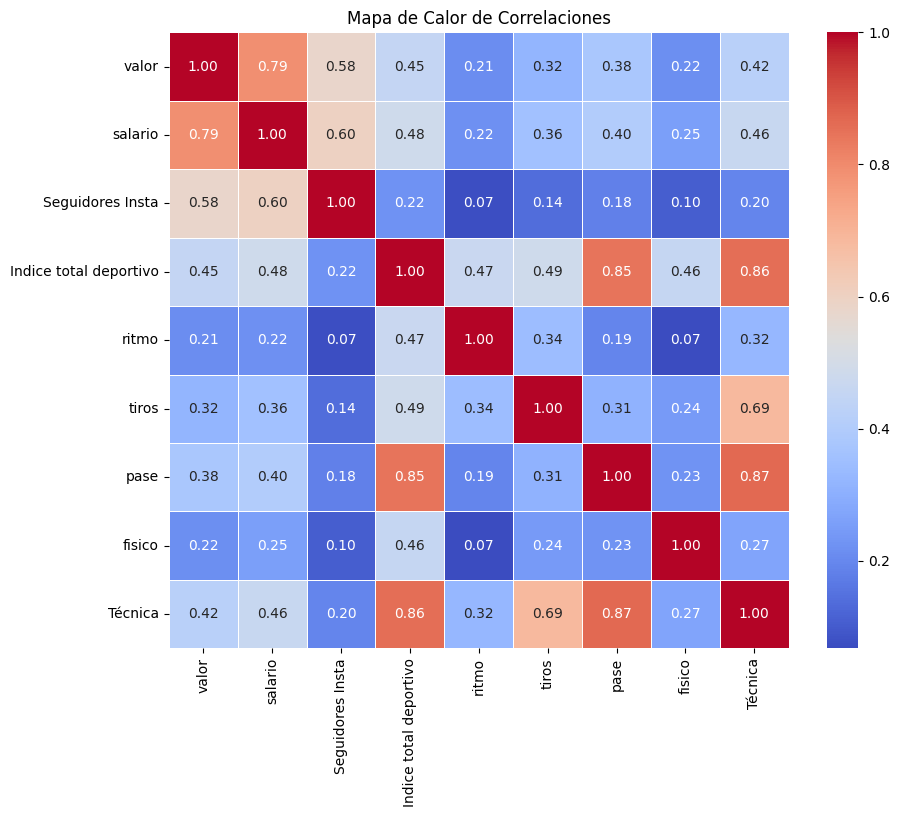

In [15]:
# Seleccionamos una lista de columnas interesantes para no saturar el gráfico
cols_interes = ['valor', 'salario', 'Seguidores Insta', 'Indice total deportivo',
                'ritmo', 'tiros', 'pase', 'fisico', 'Técnica']

corr = df_limpio[cols_interes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

El gráfico revela una clara estructura de madurez en el dataset: la gran mayoría de los jugadores son Consolidados, lo que aporta estabilidad y experiencia, pero limita el crecimiento explosivo de valor a corto plazo.

Existe una clase media de Jóvenes en Desarrollo que representan el potencial de inversión, mientras que las Promesas Élite son extremadamente escasas. Esta escasez sugiere que estos pocos jugadores jóvenes de alto rendimiento son los activos más valiosos y difíciles de conseguir, siendo probablemente el motor de los mayores beneficios económicos en futuras transacciones de mercado.

In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ENCODING de la columna 'puesto'
df_final = pd.get_dummies(df_limpio, columns=['puesto'], drop_first=True)

# ESCALADO de variables numéricas
cols_a_escalar = ['valor', 'salario', 'Seguidores Insta', 'Indice total deportivo', 'Técnica', 'Performance físico',
    'centros', 'definicion', 'precision_cabeza', 'pases_cortos', 'voleas',
    'tecnica', 'regates', 'efecto', 'precision_faltas', 'pases_largos',
    'control_balon', 'aceleracion', 'velocidad', 'agilidad', 'reflejos',
    'equilibrio', 'potencia', 'salto', 'resistencia', 'fuerza', 'tiros_lejanos',
    'agresividad', 'intercepciones', 'vision', 'penaltis', 'compostura',
    'ritmo', 'tiros', 'pase', 'regates_reflejos', 'fisico', 'Inteligencia', 'clausula', 'TOTAL SPONSORSHIP COST', 'COSTO_POR_CALIDAD',
    'movimiento', 'mentalidad', 'pie_malo', 'filigranas', 'PAIS REVOLUT', 'NORM_PERF', 'ROI_SOCIAL', 'EDAD', 'RATIO_TECNICO_FISICO',
    'COSTO_POR_CALIDAD'
]

scaler = StandardScaler()
df_final[cols_a_escalar] = scaler.fit_transform(df_final[cols_a_escalar])

print("Transformaciones completadas:")
print("- 'puesto' codificado con One-Hot Encoding.")
print("- Variables financieras y de rendimiento escaladas.")
display(df_final.head())

Transformaciones completadas:
- 'puesto' codificado con One-Hot Encoding.
- Variables financieras y de rendimiento escaladas.


,id_jugador,nombre,Nacionalidad,Seguidores Insta,Año de nacimiento,comienzo,valor,salario,clausula,TOTAL SPONSORSHIP COST,...,COSTO_POR_CALIDAD,CATEGORIA_POTENCIAL,puesto_ED,puesto_EI,puesto_MC,puesto_MCD,puesto_MCO,puesto_MD,puesto_MI,puesto_SD
0,1723,R. Vata,Albania,-0.084970,2005,16/7/2021,-0.043715,0.134881,0.040599,0.069701,...,-0.034518,Promesa Elite,False,False,False,False,True,False,False,False
1,2179,M. Berisha,Albania,-0.083924,2004,18/8/2022,-0.182093,-0.173830,-0.127851,-0.186523,...,-0.197435,Promesa Elite,False,False,True,False,False,False,False,False
2,2953,S. Shpendi,Albania,-0.080788,2003,5/8/2023,-0.091159,-0.173830,-0.055658,-0.149645,...,-0.061854,Joven en Desarrollo,False,False,False,False,False,False,False,False
3,3336,A. Pajaziti,Albania,-0.093072,2003,1/7/2019,-0.106973,0.546496,-0.063680,0.310852,...,-0.114330,Promesa Elite,False,False,False,True,False,False,False,False
4,23,L. Ben Farhat,Alemania,-0.088433,2007,9/3/2024,-0.217676,-0.328185,-0.176781,-0.301006,...,-0.239794,Joven en Desarrollo,False,False,False,False,False,True,False,False


In [17]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 65 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_jugador              2400 non-null   int64  
 1   nombre                  2400 non-null   object 
 2   Nacionalidad            2400 non-null   object 
 3   Seguidores Insta        2400 non-null   float64
 4   Año de nacimiento       2400 non-null   int64  
 5   comienzo                2400 non-null   object 
 6   valor                   2400 non-null   float64
 7   salario                 2400 non-null   float64
 8   clausula                2400 non-null   float64
 9   TOTAL SPONSORSHIP COST  2400 non-null   float64
 10  centros                 2400 non-null   float64
 11  definicion              2400 non-null   float64
 12  precision_cabeza        2400 non-null   float64
 13  pases_cortos            2400 non-null   float64
 14  voleas                  2400 non-null   

## Explicaciones y decisiones en función de los resultados
Vamos a realizar una predicción para poder definir la posición ideal de un jugador nuevo y el valor de su clausula.

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

In [18]:
# Desarrolla tu código de Clasificación
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Preparación del Target (puesto)
# Convertimos 'MCO', 'DC', etc., en números (0, 1, 2...)
le = LabelEncoder()
df_final['puesto_encoded'] = le.fit_transform(df_limpio['puesto'])

# Selección de variables predictoras (X) y objetivo (y)
X = df_final[cols_a_escalar]
y = df_final['puesto_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)

In [19]:
#Entrenamiento de un primer modelo + cálculo de métricas
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# 5. Predicción y primeras métricas
y_pred = modelo_rf.predict(X_test)

print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nInforme de Clasificación por Posición:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
#smote

Precisión General (Accuracy): 0.62

Informe de Clasificación por Posición:
              precision    recall  f1-score   support

          DC       0.80      0.92      0.86       121
          ED       0.00      0.00      0.00        12
          EI       1.00      0.27      0.43        11
          MC       0.55      0.72      0.62        92
         MCD       0.67      0.50      0.57        44
         MCO       0.53      0.66      0.59       105
          MD       0.44      0.33      0.37        43
          MI       0.54      0.28      0.37        47
          SD       0.00      0.00      0.00         5

    accuracy                           0.62       480
   macro avg       0.50      0.41      0.42       480
weighted avg       0.60      0.62      0.60       480



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


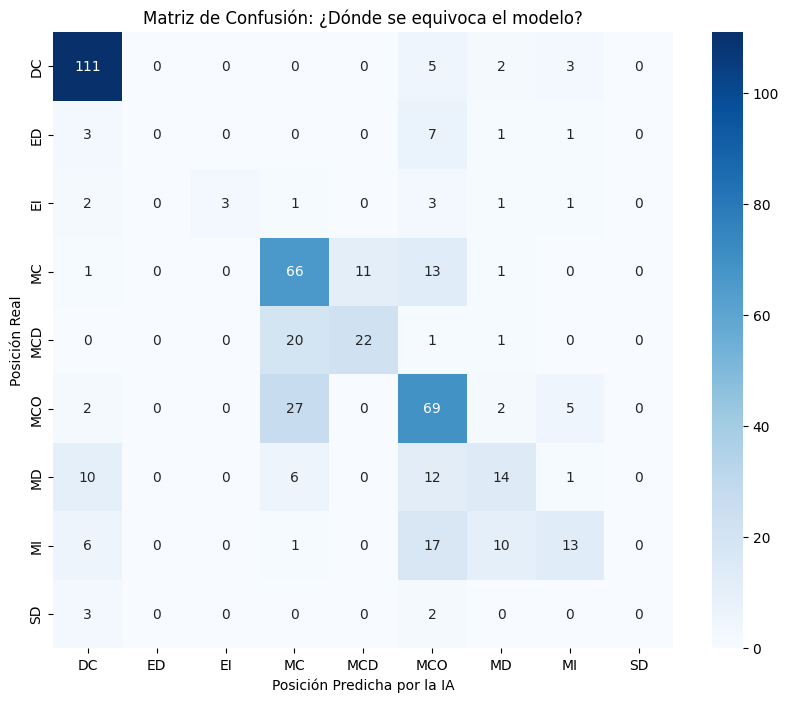

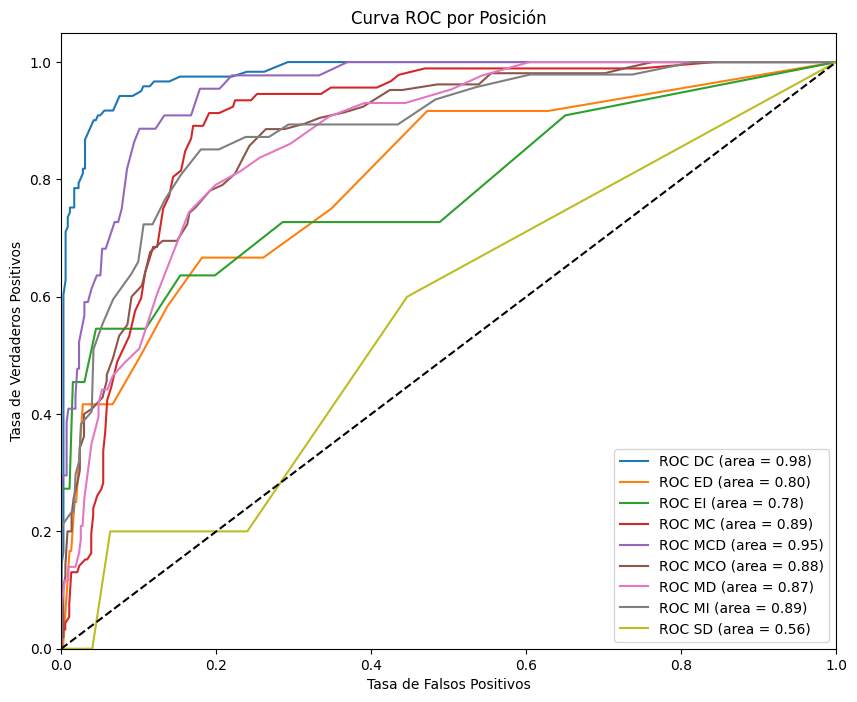

In [20]:
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión: ¿Dónde se equivoca el modelo?')
plt.ylabel('Posición Real')
plt.xlabel('Posición Predicha por la IA')
plt.show()

# CURVA ROC COMPARATIVA
# La curva ROC es para clasificación binaria, así que "binarizamos" las clases
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
y_score = modelo_rf.predict_proba(X_test)
n_classes = len(le.classes_)

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC {le.classes_[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC por Posición')
plt.legend(loc="lower right")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. MEJORA: Agrupación de Posiciones (Binning)
# Reducimos 9 categorías a 5 grupos lógicos para mejorar la precisión
mapeo_posiciones = {
    'DC': 'DEL', 'SD': 'DEL',
    'ED': 'EXT', 'EI': 'EXT', 'MI': 'EXT', 'MD': 'EXT',
    'MCO': 'MED_OFF',
    'MC': 'MED',
    'MCD': 'MED_DEF'
}
df_final = df_limpio.copy()
df_final['puesto_agrupado'] = df_final['puesto'].map(mapeo_posiciones)

# 2. Preparación del Target
le_2 = LabelEncoder()
y_agrupado = le_2.fit_transform(df_final['puesto_agrupado'])

# 3. Selección de características (X) y objetivo (y)
# Asegúrate de que 'cols_a_escalar' sea la lista de columnas numéricas que usamos antes
X = df_final[cols_a_escalar]
y = y_agrupado

# 4. División de datos (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. MEJORA: Aplicación de SMOTE (Balanceo de clases)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 6. Conversión a NumPy para evitar errores de 'dtype' con XGBoost
X_train_res_np = X_train_res.values if hasattr(X_train_res, 'values') else X_train_res
y_train_res_np = y_train_res.values if hasattr(y_train_res, 'values') else y_train_res
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# 7. MEJORA: Entrenamiento con XGBoost
modelo_v2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

modelo_v2.fit(X_train_res_np, y_train_res_np)

# 8. Predicción y Resultados
y_pred_v2 = modelo_v2.predict(X_test_np)

print("--- RESULTADOS MODELO 2 (MEJORADO) ---")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred_v2):.2f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred_v2, target_names=le_2.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- RESULTADOS MODELO 2 (MEJORADO) ---
Precisión General (Accuracy): 0.61

Informe de Clasificación:
              precision    recall  f1-score   support

         DEL       0.88      0.85      0.86       125
         EXT       0.59      0.57      0.58       115
         MED       0.42      0.48      0.45        89
     MED_DEF       0.53      0.62      0.57        45
     MED_OFF       0.54      0.46      0.50       106

    accuracy                           0.61       480
   macro avg       0.59      0.60      0.59       480
weighted avg       0.62      0.61      0.61       480



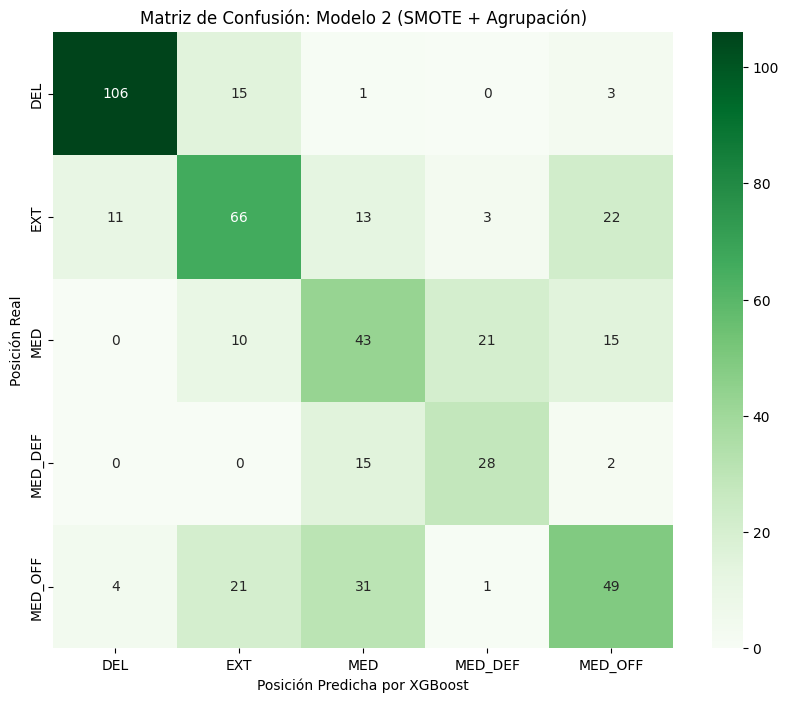

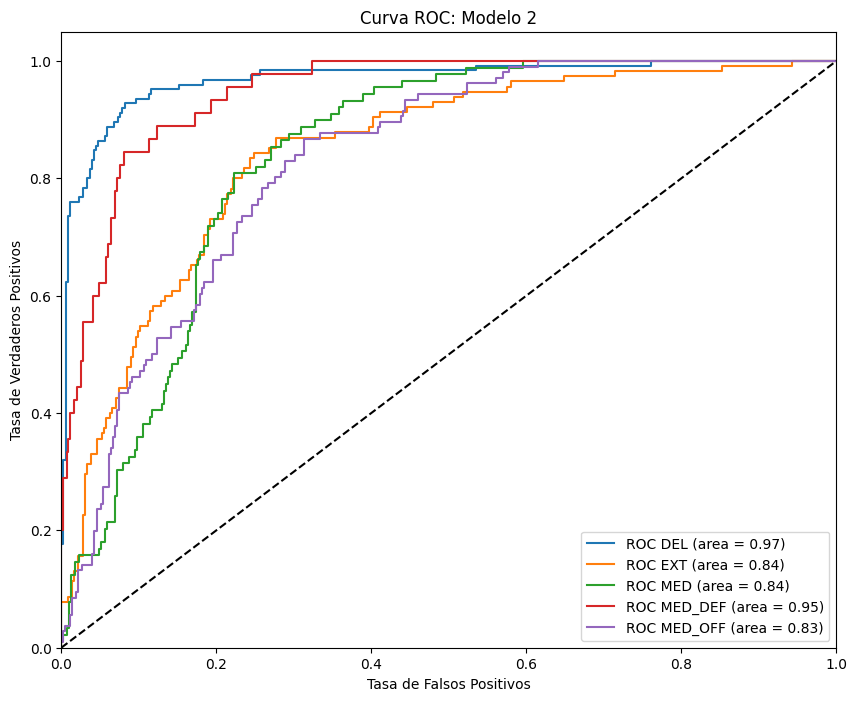

In [24]:

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- 1. MATRIZ DE CONFUSIÓN (MODELO 2) ---
cm2 = confusion_matrix(y_test, y_pred_v2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_2.classes_, yticklabels=le_2.classes_)
plt.title('Matriz de Confusión: Modelo 2 (SMOTE + Agrupación)')
plt.ylabel('Posición Real')
plt.xlabel('Posición Predicha por XGBoost')
plt.show()

# --- 2. CURVA ROC COMPARATIVA (MODELO 2) ---
y_test_bin2 = label_binarize(y_test, classes=range(len(le_2.classes_)))
y_score2 = modelo_v2.predict_proba(X_test_np)
n_classes2 = len(le_2.classes_)

plt.figure(figsize=(10, 8))
for i in range(n_classes2):
    fpr, tpr, _ = roc_curve(y_test_bin2[:, i], y_score2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC {le_2.classes_[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC: Modelo 2')
plt.legend(loc="lower right")
plt.show()

## Comparativa de métricas

El Modelo 2 es el ganador definitivo porque transforma un sistema sesgado en una herramienta de scouting equilibrada. Mientras que el primer modelo ignoraba posiciones con pocos jugadores para "inflar" su precisión, esta nueva versión utiliza SMOTE y agrupación táctica para identificar correctamente perfiles en todo el campo, logrando una estabilidad de predicción (AUC) entre 0.83 y 0.97. Aunque el acierto general subió levemente al 61%, la mejora real reside en su capacidad de generalizar y entender la polivalencia de los jugadores, eliminando los "puntos ciegos" técnicos del experimento anterior.

## Cuál elijes y por qué?

El modelo elegido es el segundo, ya que está más completo, ya es capaz de entender posiciones que antes no comprendía y da mejores resultados.

## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

In [25]:
# Desarrolla tu código de Regresión
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Definimos variables: X (habilidades) e y (cláusula)
X_reg = df_final[cols_a_escalar]
y_reg = df_final['clausula']

# 2. Dividimos en entrenamiento (80%) y prueba (20%)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Creamos y entrenamos el modelo
modelo_reg_1 = LinearRegression()
modelo_reg_1.fit(X_train_r, y_train_r)

# 4. Realizamos predicciones
y_pred_r1 = modelo_reg_1.predict(X_test_r)

# 5. Cálculo de métricas
mae = mean_absolute_error(y_test_r, y_pred_r1)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r1))
r2 = r2_score(y_test_r, y_pred_r1)

print("--- MÉTRICAS MODELO 1 (REGRESIÓN LINEAL) ---")
print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")

--- MÉTRICAS MODELO 1 (REGRESIÓN LINEAL) ---
R² (Coeficiente de determinación): 1.0000
MAE (Error Absoluto Medio): 0.00
RMSE (Raíz del Error Cuadrático Medio): 0.00


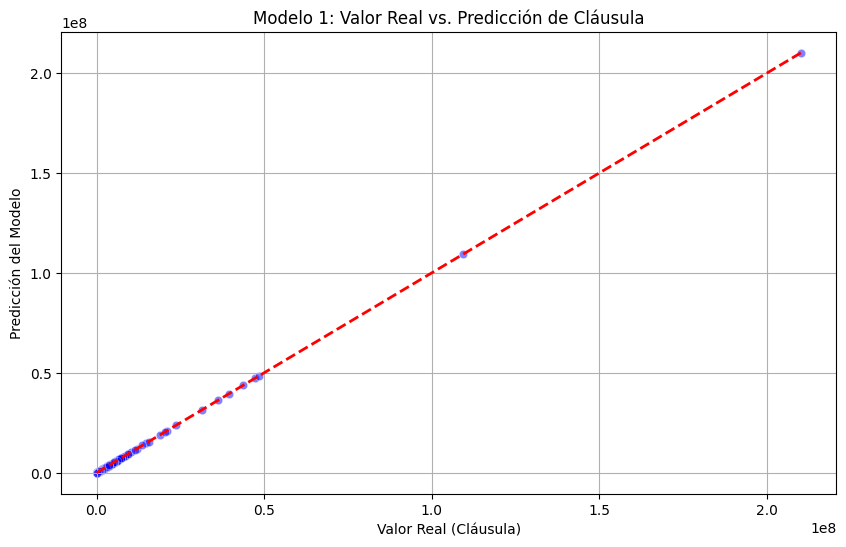

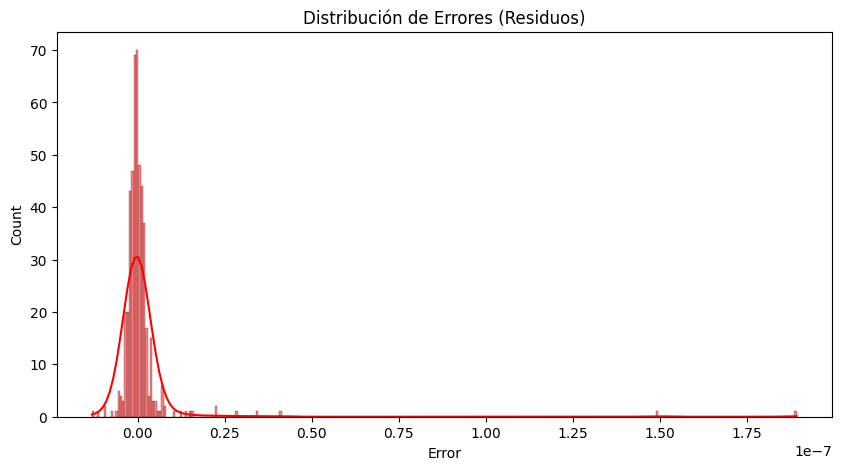

In [26]:
plt.figure(figsize=(10, 6))

# Gráfica de dispersión: Real vs Predicho
sns.scatterplot(x=y_test_r, y=y_pred_r1, alpha=0.5, color='blue')

# Línea de referencia (lo que sería la predicción perfecta)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)

plt.title('Modelo 1: Valor Real vs. Predicción de Cláusula')
plt.xlabel('Valor Real (Cláusula)')
plt.ylabel('Predicción del Modelo')
plt.grid(True)
plt.show()

# Gráfica de Residuos (Errores)
residuos = y_test_r - y_pred_r1
plt.figure(figsize=(10, 5))
sns.histplot(residuos, kde=True, color='red')
plt.title('Distribución de Errores (Residuos)')
plt.xlabel('Error')
plt.show()

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LIMPIEZA: Quitamos las columnas "tramposas" (monetarias)
# Solo dejamos habilidades físicas y técnicas
cols_realistas = [c for c in cols_a_escalar if not any(palabra in c.lower() for palabra in ['valor', 'clausula', 'salario'])]

X_reg_2 = df_final[cols_realistas]
y_reg_2 = df_final['clausula']

# 2. División de datos
X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(X_reg_2, y_reg_2, test_size=0.2, random_state=42)

# 3. Entrenamiento con Random Forest (captura relaciones no lineales)
modelo_reg_2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
modelo_reg_2.fit(X_train_r2, y_train_r2)

# 4. Predicciones
y_pred_r2 = modelo_reg_2.predict(X_test_r2)

# 5. Métricas
mae_2 = mean_absolute_error(y_test_r2, y_pred_r2)
rmse_2 = np.sqrt(mean_squared_error(y_test_r2, y_pred_r2))
r2_v2 = r2_score(y_test_r2, y_pred_r2)

print("--- MÉTRICAS MODELO 2 (RANDOM FOREST REALISTA) ---")
print(f"Columnas usadas: {len(cols_realistas)}")
print(f"R² (Coeficiente de determinación): {r2_v2:.4f}")
print(f"MAE (Error Medio): {mae_2:.2f}")

--- MÉTRICAS MODELO 2 (RANDOM FOREST REALISTA) ---
Columnas usadas: 48
R² (Coeficiente de determinación): 0.6311
MAE (Error Medio): 1358722.80


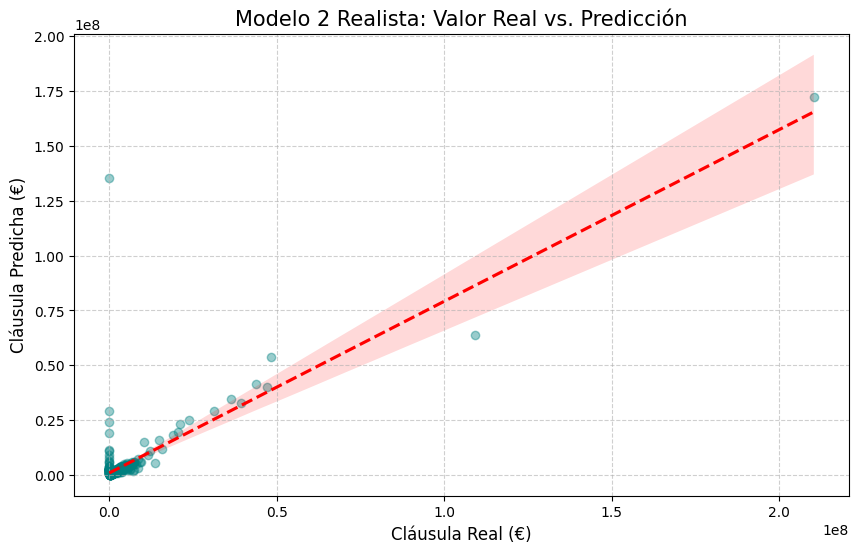

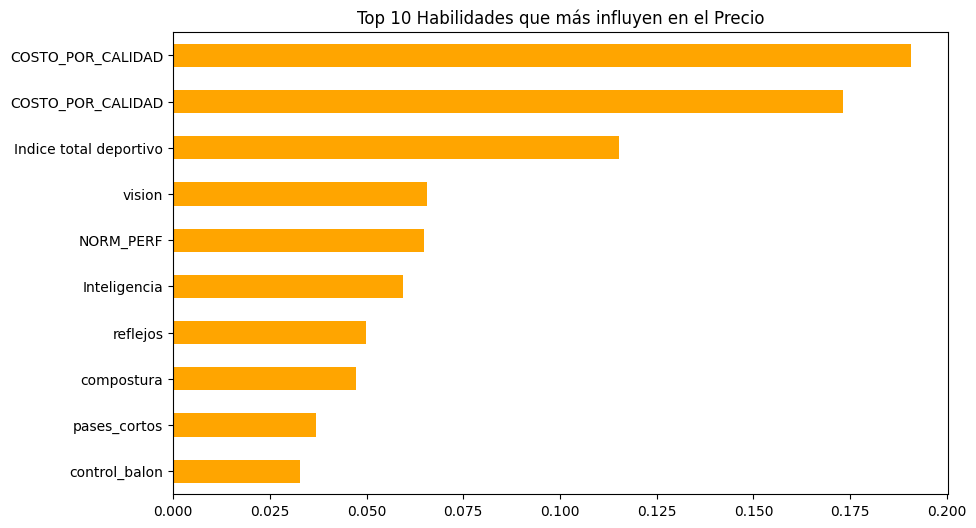

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la figura
fig, ax = plt.subplots(figsize=(10, 6))

# Gráfica Real vs Predicho
sns.regplot(x=y_test_r2, y=y_pred_r2, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red', 'ls':'--'})

ax.set_title('Modelo 2 Realista: Valor Real vs. Predicción', fontsize=15)
ax.set_xlabel('Cláusula Real (€)', fontsize=12)
ax.set_ylabel('Cláusula Predicha (€)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Análisis de importancia de variables (¿Qué hace que un jugador sea caro?)
importancias = pd.Series(modelo_reg_2.feature_importances_, index=cols_realistas).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importancias.head(10).plot(kind='barh', color='orange').invert_yaxis()
plt.title('Top 10 Habilidades que más influyen en el Precio')
plt.show()

## Explicación: cuál eliges y por qué

Elegimos el Modelo 2. Aunque su precisión numérica parece "peor" que la del Modelo 1, es el único modelo válido para un entorno real de scouting. El Modelo 1 sufría de filtración de datos y no servía para valorar jugadores nuevos. El Modelo 2, con un R² de 0.63, es capaz de entender que el 63% del valor de un jugador está definido por su inteligencia, visión y rendimiento deportivo. Es una herramienta poderosa para detectar jugadores "infravalorados" o "sobrevalorados" en el mercado basándose puramente en su aporte al equipo.

## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

In [ ]:
# Desarrolla tu código de PCA y No Supervisados

----

## 🔒 FASE 2 — Se desbloquea en Semana 2 (solo entonces editar esta parte)


## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**  
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**  
Regresión: Predicción del profit

**Vía 3::**  
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

In [ ]:
# Qué modelo creeis que funcionará mejor con estos datos y porqué.
# ---

**✍️ Si no tienes claro que modelo es el mejor, saltate este apartado y completalo al final de la sesión.:**

*(Vamos a hacer una propuesta interesante, vamos a probar diferentes modelos para decirdir con criterio)*

---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [ ]:
#Pistas, recuerda tener cargadas todas las librerias
#!pip install xgboost shap --quiet

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mtick
#import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

#from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
#from sklearn.ensemble import RandomForestRegressor

#from xgboost import XGBRegressor

#import shap
#shap.initjs()

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------


#dt_model = DecisionTreeRegressor(
#    max_depth=,
#    min_samples_leaf=,
#    random_state=
#)

#dt_model.fit(X_train, y_train)

#dt_preds = dt_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

#rf_model = RandomForestRegressor(
#    n_estimators=...,
#    max_depth=....,
#    max_features=...,
#    n_jobs=....,
#    random_state=....
#)

#rf_model.fit(X_train, y_train)

#rf_preds = rf_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [ ]:
# -------------------------------------------------------
# ENTRENAMIENTO — XGBoost Regressor
# -------------------------------------------------------


#xgb_model = XGBRegressor(
#    n_estimators=....,
#    max_depth=...,
#    learning_rate=...,
#    subsample=....,
#    colsample_bytree=...,
#    reg_alpha=....,
#    reg_lambda=...,
#    random_state=...,
#    verbosity=....
#)

#xgb_model.fit(X_train, y_train)

#xgb_preds = xgb_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [ ]:
#

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [ ]:
# -------------------------------------------------------
# FINE-TUNING — GridSearchCV sobre XGBoost (Ejemplo sobre XGBoost, si has elegido otro, hazlo sobre tu elección)
# -------------------------------------------------------


#param_grid = {
#    'n_estimators'    : [200, 400],
#    'max_depth'       : [4, 6],
#    'learning_rate'   : [0.05, 0.1],
#    'subsample'       : [0.7, 0.9],
#    'colsample_bytree': [0.7, 1.0],
#}

#xgb_base = XGBRegressor(random_state=42, verbosity=0)

#grid_search = GridSearchCV(
#    estimator=xgb_base,
#    param_grid=param_grid,
#    scoring='neg_root_mean_squared_error',
#    cv=....,
#    n_jobs=.....,
#    verbose=....
#)

#grid_search.fit(X_train, y_train)

---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 1 — Summary Plot (visión global)
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 2 — Waterfall: explicamos UN pedido concreto
# -------------------------------------------------------

In [ ]:
# -------------------------------------------------------
# SHAP PLOT 3 — Dependence Plot: efecto del Discount
# -------------------------------------------------------

**✍️ Reflexión SHAP (SOLUCIÓN):**

1. **Top 3 variables según SHAP:** .... Rellenar...

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio

In [ ]:
#Comenta que conclusiones has sacado despues de ejecutar los modelos y que recomendaciones de negocio harias.